In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
ruta_suelo = '/content/drive/MyDrive/suelo_clay_guayas.tif'
ruta_dem = '/content/drive/MyDrive/DEM_GUAYAS_2.tif'
ruta_shp = '/content/drive/MyDrive/guayas_parroquias_rurales.shp.gpkg'

chirps_2020 = '/content/drive/MyDrive/chirps-v2.0.2020.02.21.tif'
chirps_2021 = '/content/drive/MyDrive/chirps-v2.0.2021.01.18.tif'
chirps_2022 = '/content/drive/MyDrive/chirps-v2.0.2022.01.26.tif'
chirps_2023 = '/content/drive/MyDrive/chirps-v2.0.2023.02.11.tif'

In [3]:
import os

print(os.path.exists(ruta_suelo))
print(os.path.exists(ruta_dem))
print(os.path.exists(ruta_shp))
print(os.path.exists(chirps_2020))

True
True
True
True


**DEM**

In [ ]:
import rasterio

with rasterio.open(ruta_dem) as src:
    print("Nombre del archivo:", ruta_dem)
    print("Sistema de coordenadas:", src.crs)
    print("Ancho:", src.width)
    print("Alto:", src.height)
    print("Número de bandas:", src.count)
    print("Resolución:", src.res)
    print("Tipo de dato:", src.dtypes[0])
    print("Valor NoData:", src.nodata)
    print("Extensión:", src.bounds)

Nombre del archivo: /content/drive/MyDrive/DEM_GUAYAS_2.tif
Sistema de coordenadas: EPSG:4326
Ancho: 5260
Alto: 7990
Número de bandas: 1
Resolución: (0.0002777777777777773, 0.0002777777777777777)
Tipo de dato: float32
Valor NoData: None
Extensión: BoundingBox(left=-80.56347222222222, bottom=-3.0640277777777776, right=-79.10236111111111, top=-0.8445833333333334)


In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

ruta_dem_utm = '/content/drive/MyDrive/DEM_GUAYAS_UTM.tif'

with rasterio.open(ruta_dem) as src:
    transform, width, height = calculate_default_transform(
        src.crs, 'EPSG:32717', src.width, src.height, *src.bounds
    )

    kwargs = src.meta.copy()
    kwargs.update({
        'crs': 'EPSG:32717',
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(ruta_dem_utm, 'w', **kwargs) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs='EPSG:32717',
            resampling=Resampling.bilinear
        )

In [ ]:
import rasterio

with rasterio.open(ruta_dem_utm) as src:
    print(src.crs)
    print(src.res)

EPSG:32717
(30.767016286153034, 30.767016286153034)


In [ ]:
import geopandas as gpd

gdf = gpd.read_file(ruta_shp)

parroquias = gdf['NAME_3'].unique()

for i, p in enumerate(parroquias, 1):
    print(f"{i}. {p}")

1. SanJacinto
2. JuanBautistaAguirre(LosTinto
3. Laurel
4. Limonal
5. LosLojas(EnriqueBaquerizoMor
6. ElRosario
7. Guayas(PuebloNuevo)
8. JuanGomezRendon(Progreso)
9. Morro
10. Posorja
11. Puna
12. Tenguel
13. Chobo
14. MariscalSucre(Huaques)
15. RobertoAstudillo(Cab.EnCruce
16. JesusMaria
17. SanCarlos
18. SantaRosaDeFlandes
19. Taura
20. Sabanilla
21. ValleDeLaVirgen
22. Tarifa
23. GeneralPedroJ.Montero(Bolich
24. VirgenDeFatima
25. YaguachiViejo(Cone)
26. CoronelLorenzoDeGaraicoa(Ped
27. GeneralVernaza(DosEsteros)
28. Junquillal
29. LaVictoria(Ñauza)


In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask

ruta_dem_recortado = '/content/drive/MyDrive/DEM_GUAYAS_RECORTADO.tif'

gdf = gpd.read_file(ruta_shp)

with rasterio.open(ruta_dem_utm) as src:
    gdf = gdf.to_crs(src.crs)

    geometrias = gdf.geometry.values

    out_image, out_transform = mask(src, geometrias, crop=True)

    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

    with rasterio.open(ruta_dem_recortado, "w", **out_meta) as dest:
        dest.write(out_image)

In [ ]:
import rasterio

with rasterio.open(ruta_dem_recortado) as src:
    print(src.bounds)

BoundingBox(left=559336.094661619, bottom=9661216.881091721, right=692772.6442946647, top=9906645.370006364)


In [ ]:
import numpy as np
import rasterio

ruta_pendiente = '/content/drive/MyDrive/PENDIENTE_GUAYAS.tif'

with rasterio.open(ruta_dem_recortado) as src:
    dem = src.read(1).astype('float32')
    transform = src.transform
    perfil = src.profile.copy()
    nodata = src.nodata

    if nodata is not None:
        dem[dem == nodata] = np.nan

    xres = transform.a
    yres = abs(transform.e)

    dy, dx = np.gradient(dem, yres, xres)
    pendiente = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2))).astype('float32')

    perfil.update(dtype='float32', count=1, nodata=np.nan)

    with rasterio.open(ruta_pendiente, 'w', **perfil) as dst:
        dst.write(pendiente, 1)

In [ ]:
import rasterio
import numpy as np

with rasterio.open(ruta_pendiente) as src:
    pendiente = src.read(1)
    print(src.bounds)
    print(np.nanmin(pendiente))
    print(np.nanmax(pendiente))

BoundingBox(left=559336.094661619, bottom=9661216.881091721, right=692772.6442946647, top=9906645.370006364)
0.0
88.26339


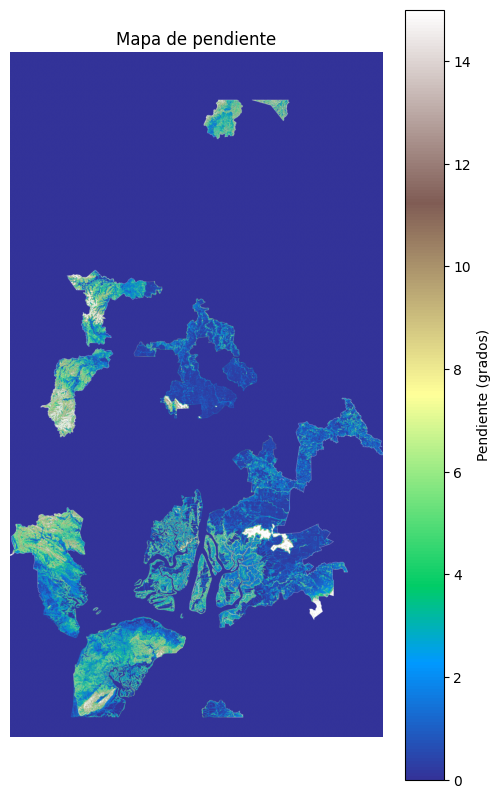

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np

with rasterio.open(ruta_pendiente) as src:
    pendiente = src.read(1)

plt.figure(figsize=(6,10))
plt.imshow(pendiente, cmap='terrain', vmin=0, vmax=15)
plt.colorbar(label='Pendiente (grados)')
plt.title('Mapa de pendiente')
plt.axis('off')
plt.show()

In [ ]:
ruta_curvatura = "/content/drive/MyDrive/CURVATURA_GUAYAS.tif"

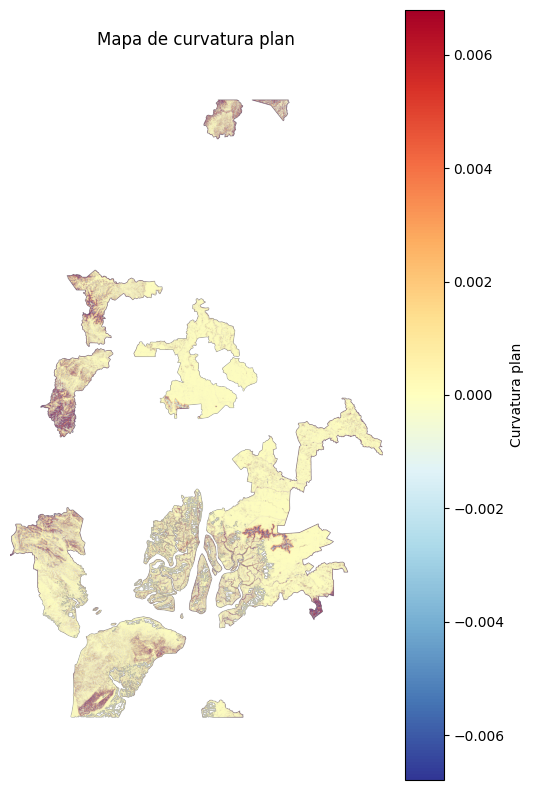

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

with rasterio.open(ruta_curvatura) as src:
    curv = src.read(1).astype('float32')

curv[curv == 0] = np.nan

p2 = np.nanpercentile(curv, 2)
p98 = np.nanpercentile(curv, 98)
v = max(abs(p2), abs(p98))

plt.figure(figsize=(6,10))
plt.imshow(curv, cmap='RdYlBu_r', vmin=-v, vmax=v)
plt.colorbar(label='Curvatura plan')
plt.title('Mapa de curvatura plan')
plt.axis('off')
plt.show()

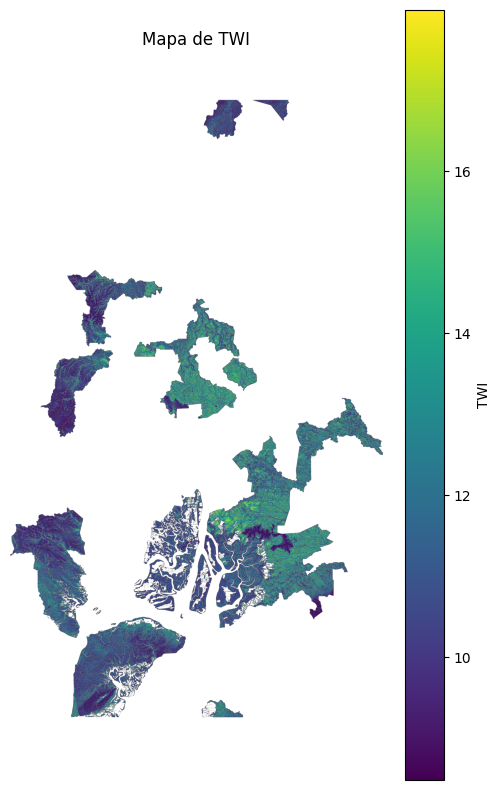

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

ruta_dem = '/content/drive/MyDrive/DEM_GUAYAS_RECORTADO.tif'
ruta_acc = '/content/drive/MyDrive/ACUMULACION_FLUJO_GUAYAS.tif'
ruta_twi = '/content/drive/MyDrive/TWI_GUAYAS.tif'

with rasterio.open(ruta_dem) as src:
    dem = src.read(1).astype('float32')
    perfil = src.profile.copy()
    transform = src.transform
    res = src.res[0]

with rasterio.open(ruta_acc) as src:
    acc = src.read(1).astype('float32')

dem[dem <= 0] = np.nan
acc[acc <= 0] = np.nan

dy, dx = np.gradient(dem, res, res)
pendiente = np.sqrt(dx**2 + dy**2)

pendiente[pendiente == 0] = np.nan

area = acc * (res**2)

twi = np.log(area / pendiente)

twi[np.isinf(twi)] = np.nan

perfil.pop('blockxsize', None)
perfil.pop('blockysize', None)
perfil.pop('tiled', None)

perfil.update(dtype='float32', count=1)

with rasterio.open(ruta_twi, 'w', **perfil) as dst:
    dst.write(twi.astype('float32'), 1)

p2 = np.nanpercentile(twi, 2)
p98 = np.nanpercentile(twi, 98)

plt.figure(figsize=(6,10))
plt.imshow(twi, cmap='viridis', vmin=p2, vmax=p98)
plt.colorbar(label='TWI')
plt.title('Mapa de TWI')
plt.axis('off')
plt.show()

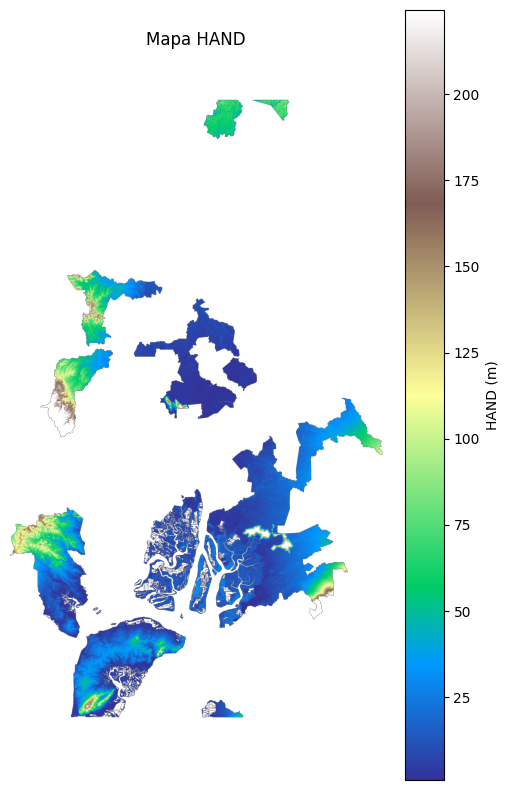

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

ruta_dem = '/content/drive/MyDrive/DEM_GUAYAS_RECORTADO.tif'
ruta_acc = '/content/drive/MyDrive/ACUMULACION_FLUJO_GUAYAS.tif'
ruta_hand = '/content/drive/MyDrive/HAND_GUAYAS.tif'

with rasterio.open(ruta_dem) as src:
    dem = src.read(1).astype('float32')
    perfil = src.profile.copy()

with rasterio.open(ruta_acc) as src:
    acc = src.read(1).astype('float32')

dem[dem <= 0] = np.nan
acc[acc <= 0] = np.nan

umbral = np.nanpercentile(acc, 90)

drenaje = acc >= umbral

hand = np.full_like(dem, np.nan)

hand[drenaje] = 0

min_drenaje = np.nanmin(dem[drenaje])

hand = dem - min_drenaje

hand[hand < 0] = 0

perfil.pop('blockxsize', None)
perfil.pop('blockysize', None)
perfil.pop('tiled', None)

perfil.update(dtype='float32', count=1)

with rasterio.open(ruta_hand, 'w', **perfil) as dst:
    dst.write(hand.astype('float32'), 1)

p2 = np.nanpercentile(hand, 2)
p98 = np.nanpercentile(hand, 98)

plt.figure(figsize=(6,10))
plt.imshow(hand, cmap='terrain', vmin=p2, vmax=p98)
plt.colorbar(label='HAND (m)')
plt.title('Mapa HAND')
plt.axis('off')
plt.show()


In [ ]:
ruta_acumulacion = "/content/drive/MyDrive/ACUMULACION_FLUJO_GUAYAS.tif"

In [ ]:
ruta_pendiente = "/content/drive/MyDrive/PENDIENTE_GUAYAS.tif"

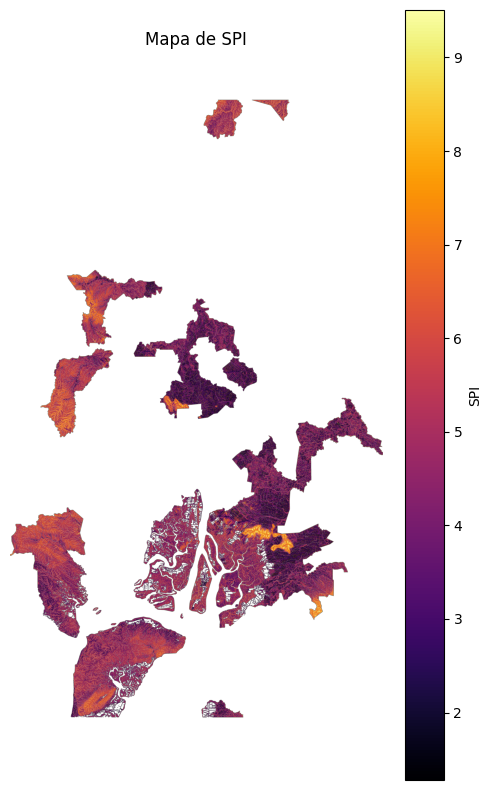

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

ruta_pendiente = '/content/drive/MyDrive/PENDIENTE_GUAYAS.tif'
ruta_acumulacion = '/content/drive/MyDrive/ACUMULACION_FLUJO_GUAYAS.tif'
ruta_spi = '/content/drive/MyDrive/SPI_GUAYAS_REAL.tif'

with rasterio.open(ruta_pendiente) as src1:
    pendiente = src1.read(1).astype('float32')
    perfil = src1.profile.copy()
    res = src1.res[0]

with rasterio.open(ruta_acumulacion) as src2:
    acc = src2.read(1).astype('float32')

pendiente[pendiente <= 0] = np.nan
acc[acc <= 0] = np.nan

pendiente_rad = np.radians(pendiente)

area = acc * (res ** 2)

spi = area * np.tan(pendiente_rad)

spi[np.isinf(spi)] = np.nan

spi = np.log1p(spi)

perfil.pop('blockxsize', None)
perfil.pop('blockysize', None)
perfil.pop('tiled', None)

perfil.update(dtype='float32', count=1)

with rasterio.open(ruta_spi, 'w', **perfil) as dst:
    dst.write(spi.astype('float32'), 1)

p2 = np.nanpercentile(spi, 2)
p98 = np.nanpercentile(spi, 98)

plt.figure(figsize=(6,10))
plt.imshow(spi, cmap='inferno', vmin=p2, vmax=p98)
plt.colorbar(label='SPI')
plt.title('Mapa de SPI')
plt.axis('off')
plt.show()

**CHIRPS**

In [ ]:
import rasterio

ruta_dem = '/content/drive/MyDrive/DEM_GUAYAS_RECORTADO.tif'

with rasterio.open(ruta_dem) as src:
    dem = src.read(1)
    perfil = src.profile
    transform = src.transform
    crs = src.crs
    resolucion = src.res
    shape = dem.shape

print("Shape DEM:", shape)
print("Resolución:", resolucion)
print("CRS:", crs)

Shape DEM: (7977, 4337)
Resolución: (30.767016286153034, 30.767016286153034)
CRS: EPSG:32717


In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

ruta_chirps = '/content/drive/MyDrive/chirps-v2.0.2020.02.21.tif'

with rasterio.open(ruta_dem) as dem_src:
    dem_shape = dem_src.shape
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs

with rasterio.open(ruta_chirps) as src:
    chirps = src.read(1)
    chirps_transform = src.transform
    chirps_crs = src.crs

chirps_alineado = np.empty(dem_shape, dtype=np.float32)

reproject(
    source=chirps,
    destination=chirps_alineado,
    src_transform=chirps_transform,
    src_crs=chirps_crs,
    dst_transform=dem_transform,
    dst_crs=dem_crs,
    resampling=Resampling.bilinear
)

chirps_alineado[chirps_alineado < 0] = np.nan

print("Shape CHIRPS alineado:", chirps_alineado.shape)

Shape CHIRPS alineado: (7977, 4337)


In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

rutas_chirps = [
    '/content/drive/MyDrive/chirps-v2.0.2020.02.21.tif',
    '/content/drive/MyDrive/chirps-v2.0.2021.01.18.tif',
    '/content/drive/MyDrive/chirps-v2.0.2022.01.26.tif',
    '/content/drive/MyDrive/chirps-v2.0.2023.02.11.tif'
]

with rasterio.open(ruta_dem) as dem_src:
    dem_shape = dem_src.shape
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs

chirps_alineados = []

for ruta in rutas_chirps:
    with rasterio.open(ruta) as src:
        data = src.read(1)
        transform = src.transform
        crs = src.crs

    alineado = np.empty(dem_shape, dtype=np.float32)

    reproject(
        source=data,
        destination=alineado,
        src_transform=transform,
        src_crs=crs,
        dst_transform=dem_transform,
        dst_crs=dem_crs,
        resampling=Resampling.bilinear
    )

    alineado[alineado < 0] = np.nan

    chirps_alineados.append(alineado)

for i, arr in enumerate(chirps_alineados):
    print(f"Año {i} shape:", arr.shape)

Año 0 shape: (7977, 4337)
Año 1 shape: (7977, 4337)
Año 2 shape: (7977, 4337)
Año 3 shape: (7977, 4337)


In [ ]:
precip_acumulada = (
    chirps_alineados[0] +
    chirps_alineados[1] +
    chirps_alineados[2] +
    chirps_alineados[3]
)

print("Shape:", precip_acumulada.shape)
print("Min / Max:", np.nanmin(precip_acumulada), np.nanmax(precip_acumulada))

Shape: (7977, 4337)
Min / Max: 0.0 170.41534


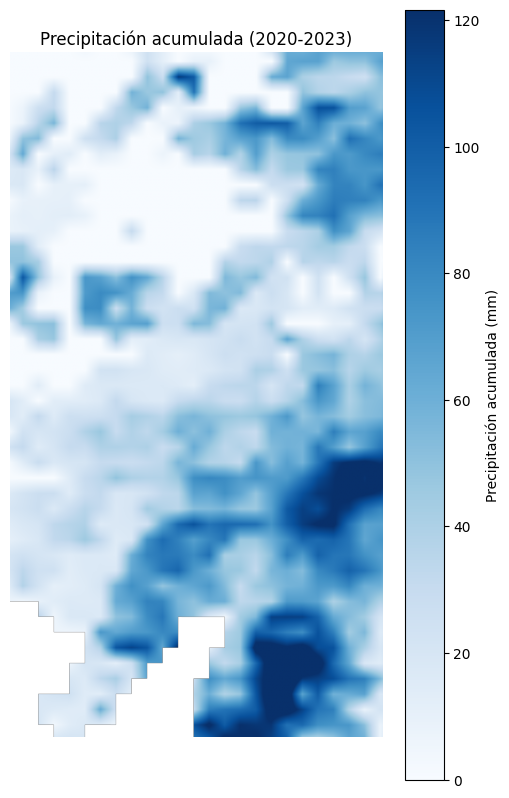

In [ ]:
import matplotlib.pyplot as plt

p2 = np.nanpercentile(precip_acumulada, 2)
p98 = np.nanpercentile(precip_acumulada, 98)

plt.figure(figsize=(6,10))
plt.imshow(precip_acumulada, cmap='Blues', vmin=p2, vmax=p98)
plt.colorbar(label='Precipitación acumulada (mm)')
plt.title('Precipitación acumulada (2020-2023)')
plt.axis('off')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

intensidad_precipitacion = precip_acumulada / 4

print("Shape:", intensidad_precipitacion.shape)
print("Min / Max:", np.nanmin(intensidad_precipitacion), np.nanmax(intensidad_precipitacion))

Shape: (7977, 4337)
Min / Max: 0.0 42.603836


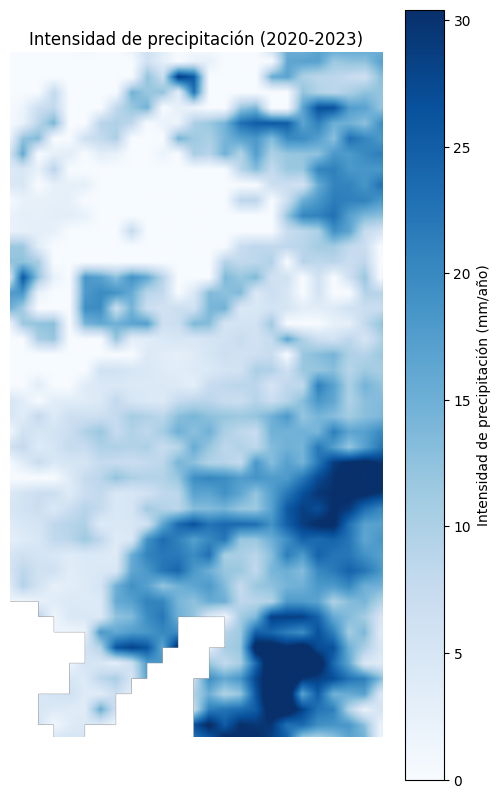

In [ ]:
p2 = np.nanpercentile(intensidad_precipitacion, 2)
p98 = np.nanpercentile(intensidad_precipitacion, 98)

plt.figure(figsize=(6,10))
plt.imshow(intensidad_precipitacion, cmap='Blues', vmin=p2, vmax=p98)
plt.colorbar(label='Intensidad de precipitación (mm/año)')
plt.title('Intensidad de precipitación (2020-2023)')
plt.axis('off')
plt.show()

In [ ]:
data = precip_acumulada.flatten()
data = data[~np.isnan(data)]

media = np.mean(data)
std = np.std(data)

spi = (precip_acumulada - media) / std

print("Min / Max:", np.nanmin(spi), np.nanmax(spi))

Min / Max: -1.266866 3.989941


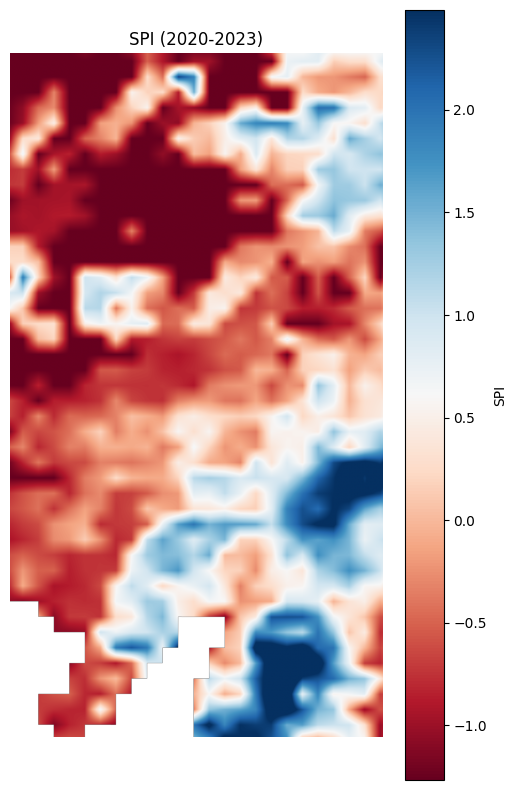

In [ ]:
p2 = np.nanpercentile(spi, 2)
p98 = np.nanpercentile(spi, 98)

plt.figure(figsize=(6,10))
plt.imshow(spi, cmap='RdBu', vmin=p2, vmax=p98)
plt.colorbar(label='SPI')
plt.title('SPI (2020-2023)')
plt.axis('off')
plt.show()

CHIRPS CORREGIDO

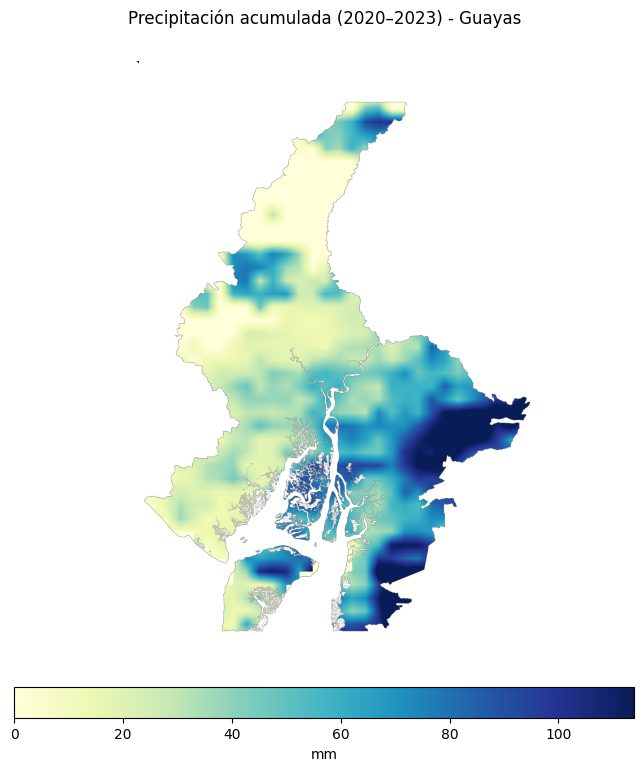

In [ ]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from rasterio.warp import reproject, Resampling

ruta_dem = "/content/drive/MyDrive/DEM_GUAYAS_2.tif"

rutas = [
"/content/drive/MyDrive/chirps-v2.0.2020.02.21.tif",
"/content/drive/MyDrive/chirps-v2.0.2021.01.18.tif",
"/content/drive/MyDrive/chirps-v2.0.2022.01.26.tif",
"/content/drive/MyDrive/chirps-v2.0.2023.02.11.tif"
]

ruta_shp = "/content/drive/MyDrive/guayas_parroquias_rurales.shp.gpkg"

with rasterio.open(ruta_dem) as dem_src:
    dem = dem_src.read(1)
    transform = dem_src.transform
    crs = dem_src.crs
    shape = dem.shape

chirps_total = np.zeros(shape, dtype=np.float32)

for ruta in rutas:
    with rasterio.open(ruta) as src:
        temp = np.empty(shape, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=temp,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=crs,
            resampling=Resampling.bilinear
        )

        chirps_total += np.nan_to_num(temp)

mask = dem > 0
chirps_total = np.where(mask, chirps_total, np.nan)

gdf = gpd.read_file(ruta_shp)
gdf = gdf.to_crs(crs)

vmin = np.nanpercentile(chirps_total, 5)
vmax = np.nanpercentile(chirps_total, 95)

fig, ax = plt.subplots(figsize=(8,10))

img = ax.imshow(chirps_total, cmap='YlGnBu', vmin=vmin, vmax=vmax)

gdf.boundary.plot(ax=ax, color='black', linewidth=0.6)

ax.set_title("Precipitación acumulada (2020–2023) - Guayas")
ax.axis('off')

cbar = plt.colorbar(img, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label("mm")

plt.show()

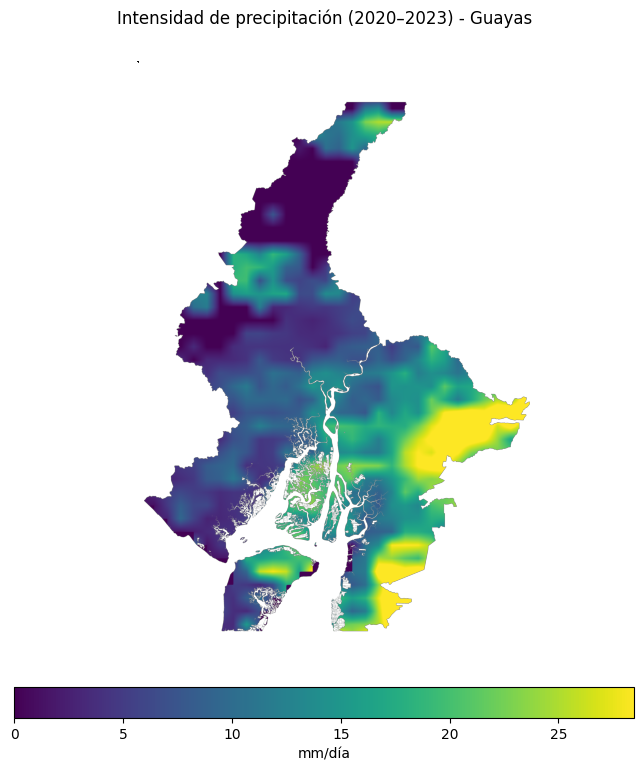

In [ ]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from rasterio.warp import reproject, Resampling

ruta_dem = "/content/drive/MyDrive/DEM_GUAYAS_2.tif"

rutas = [
"/content/drive/MyDrive/chirps-v2.0.2020.02.21.tif",
"/content/drive/MyDrive/chirps-v2.0.2021.01.18.tif",
"/content/drive/MyDrive/chirps-v2.0.2022.01.26.tif",
"/content/drive/MyDrive/chirps-v2.0.2023.02.11.tif"
]

ruta_shp = "/content/drive/MyDrive/guayas_parroquias_rurales.shp.gpkg"

with rasterio.open(ruta_dem) as dem_src:
    dem = dem_src.read(1)
    transform = dem_src.transform
    crs = dem_src.crs
    shape = dem.shape

chirps_total = np.zeros(shape, dtype=np.float32)

for ruta in rutas:
    with rasterio.open(ruta) as src:
        temp = np.empty(shape, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=temp,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=crs,
            resampling=Resampling.bilinear
        )

        chirps_total += np.nan_to_num(temp)

mask = dem > 0
chirps_total = np.where(mask, chirps_total, np.nan)

n = len(rutas)
intensidad = chirps_total / n

gdf = gpd.read_file(ruta_shp)
gdf = gdf.to_crs(crs)

vmin = np.nanpercentile(intensidad, 5)
vmax = np.nanpercentile(intensidad, 95)

fig, ax = plt.subplots(figsize=(8,10))

img = ax.imshow(intensidad, cmap='viridis', vmin=vmin, vmax=vmax)

gdf.boundary.plot(ax=ax, color='black', linewidth=0.6)

ax.set_title("Intensidad de precipitación (2020–2023) - Guayas")
ax.axis('off')

cbar = plt.colorbar(img, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label("mm/día")

plt.show()

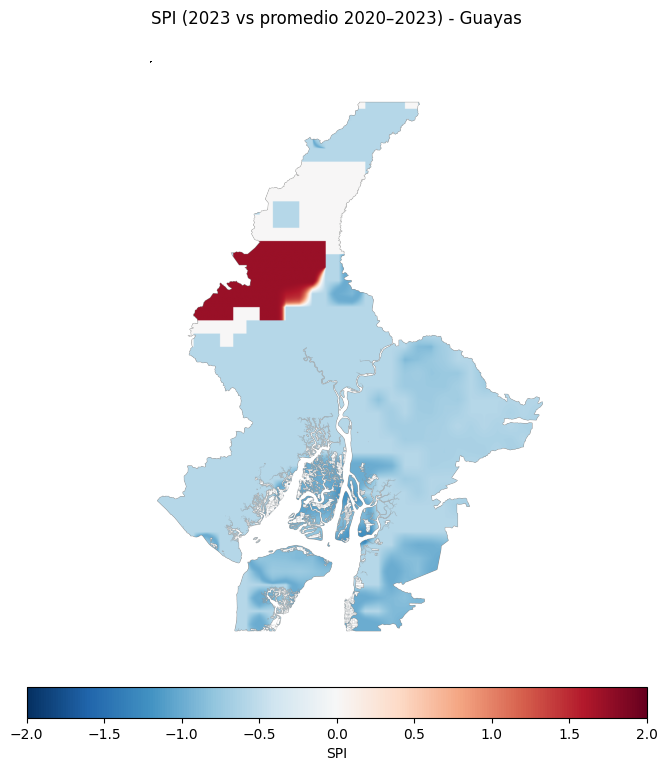

In [ ]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from rasterio.warp import reproject, Resampling

ruta_dem = "/content/drive/MyDrive/DEM_GUAYAS_2.tif"

rutas = [
"/content/drive/MyDrive/chirps-v2.0.2020.02.21.tif",
"/content/drive/MyDrive/chirps-v2.0.2021.01.18.tif",
"/content/drive/MyDrive/chirps-v2.0.2022.01.26.tif",
"/content/drive/MyDrive/chirps-v2.0.2023.02.11.tif"
]

ruta_shp = "/content/drive/MyDrive/guayas_parroquias_rurales.shp.gpkg"

with rasterio.open(ruta_dem) as dem_src:
    dem = dem_src.read(1)
    transform = dem_src.transform
    crs = dem_src.crs
    shape = dem.shape

stack = []

for ruta in rutas:
    with rasterio.open(ruta) as src:
        temp = np.empty(shape, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=temp,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=crs,
            resampling=Resampling.bilinear
        )

        stack.append(temp)

stack = np.stack(stack)

media = np.nanmean(stack, axis=0)
std = np.nanstd(stack, axis=0)

std = np.where(std == 0, 1, std)

spi = (stack[-1] - media) / std

mask = dem > 0
spi = np.where(mask, spi, np.nan)

gdf = gpd.read_file(ruta_shp)
gdf = gdf.to_crs(crs)

fig, ax = plt.subplots(figsize=(8,10))

img = ax.imshow(spi, cmap='RdBu_r', vmin=-2, vmax=2)

gdf.boundary.plot(ax=ax, color='black', linewidth=0.6)

ax.set_title("SPI (2023 vs promedio 2020–2023) - Guayas")
ax.axis('off')

cbar = plt.colorbar(img, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label("SPI")

plt.show()

**SUELO- SOILGRIDS**

In [ ]:
import rasterio

ruta_suelo = '/content/drive/MyDrive/suelo_clay_guayas.tif'

with rasterio.open(ruta_suelo) as src:
    suelo = src.read(1)
    perfil_suelo = src.profile
    transform_suelo = src.transform
    crs_suelo = src.crs
    shape_suelo = suelo.shape
    resolucion = src.res

print("Shape suelo:", shape_suelo)
print("Resolución:", resolucion)
print("CRS:", crs_suelo)

Shape suelo: (928, 529)
Resolución: (0.002259887005671079, 0.002389486260775862)
CRS: EPSG:4326


In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

ruta_dem = '/content/drive/MyDrive/DEM_GUAYAS_RECORTADO.tif'
ruta_suelo = '/content/drive/MyDrive/suelo_clay_guayas.tif'

with rasterio.open(ruta_dem) as dem_src:
    dem_shape = dem_src.shape
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs

with rasterio.open(ruta_suelo) as src:
    suelo = src.read(1)
    suelo_transform = src.transform
    suelo_crs = src.crs

suelo_alineado = np.empty(dem_shape, dtype=np.float32)

reproject(
    source=suelo,
    destination=suelo_alineado,
    src_transform=suelo_transform,
    src_crs=suelo_crs,
    dst_transform=dem_transform,
    dst_crs=dem_crs,
    resampling=Resampling.bilinear
)

suelo_alineado[suelo_alineado < 0] = np.nan

print("Shape suelo alineado:", suelo_alineado.shape)
print("Min / Max:", np.nanmin(suelo_alineado), np.nanmax(suelo_alineado))

Shape suelo alineado: (7977, 4337)
Min / Max: 0.0 385.6419


In [ ]:
suelo_alineado[suelo_alineado <= 0] = np.nan

print("Min / Max:", np.nanmin(suelo_alineado), np.nanmax(suelo_alineado))

Min / Max: 2.521081e-05 385.6419


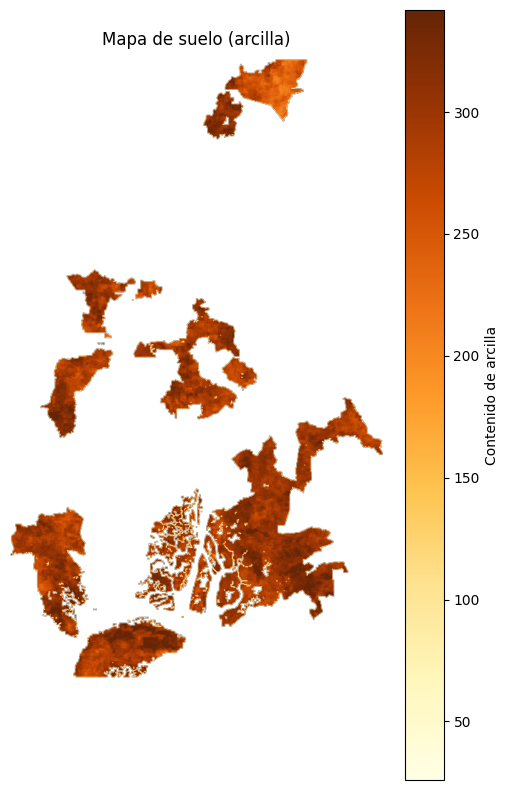

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

p2 = np.nanpercentile(suelo_alineado, 2)
p98 = np.nanpercentile(suelo_alineado, 98)

plt.figure(figsize=(6,10))
plt.imshow(suelo_alineado, cmap='YlOrBr', vmin=p2, vmax=p98)
plt.colorbar(label='Contenido de arcilla')
plt.title('Mapa de suelo (arcilla)')
plt.axis('off')
plt.show()

**SENTINEL 1**

In [ ]:
import rasterio
import geopandas as gpd

base = "/content/drive/MyDrive/"

archivos = [
    "DEM_GUAYAS_2.tif",
    "SENTINEL_GUAYAS_2020.tif",
    "SENTINEL_GUAYAS_2023.tif",
    "chirps-v2.0.2023.02.11.tif",
    "suelo_clay_guayas.tif"
]

for f in archivos:
    with rasterio.open(base + f) as src:
        print(f, "→", src.crs)

# shapefile
shp = gpd.read_file(base + "guayas_parroquias_rurales.shp.gpkg")
print("Parroquias →", shp.crs)

DEM_GUAYAS_2.tif → EPSG:4326
SENTINEL_GUAYAS_2020.tif → EPSG:4326
SENTINEL_GUAYAS_2023.tif → EPSG:32717
chirps-v2.0.2023.02.11.tif → EPSG:4326
suelo_clay_guayas.tif → EPSG:4326
Parroquias → EPSG:4326


In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas as gpd

base = "/content/drive/MyDrive/"

def reproyectar_raster(entrada, salida):
    with rasterio.open(entrada) as src:
        transform, width, height = calculate_default_transform(
            src.crs, "EPSG:32717", src.width, src.height, *src.bounds
        )

        kwargs = src.meta.copy()
        kwargs.update({
            'crs': "EPSG:32717",
            'transform': transform,
            'width': width,
            'height': height
        })

        with rasterio.open(salida, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs="EPSG:32717",
                    resampling=Resampling.bilinear
                )

reproyectar_raster(base+"DEM_GUAYAS_2.tif", base+"DEM_32717.tif")
reproyectar_raster(base+"SENTINEL_GUAYAS_2020.tif", base+"SENTINEL_2020_32717.tif")
reproyectar_raster(base+"chirps-v2.0.2023.02.11.tif", base+"CHIRPS_32717.tif")
reproyectar_raster(base+"suelo_clay_guayas.tif", base+"SUELO_32717.tif")

shp = gpd.read_file(base+"guayas_parroquias_rurales.shp.gpkg")
shp_utm = shp.to_crs(epsg=32717)
shp_utm.to_file(base+"parroquias_32717.gpkg", driver="GPKG")

In [ ]:
import rasterio
import geopandas as gpd

base = "/content/drive/MyDrive/"

archivos = [
    "DEM_32717.tif",
    "SENTINEL_2020_32717.tif",
    "SENTINEL_GUAYAS_2023.tif",
    "CHIRPS_32717.tif",
    "SUELO_32717.tif"
]

for f in archivos:
    with rasterio.open(base + f) as src:
        print(f, "→", src.crs)

shp = gpd.read_file(base + "parroquias_32717.gpkg")
print("Parroquias →", shp.crs)

DEM_32717.tif → EPSG:32717
SENTINEL_2020_32717.tif → EPSG:32717
SENTINEL_GUAYAS_2023.tif → EPSG:32717
CHIRPS_32717.tif → EPSG:32717
SUELO_32717.tif → EPSG:32717
Parroquias → EPSG:32717


In [ ]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd

base = "/content/drive/MyDrive/"

shp = gpd.read_file(base + "parroquias_32717.gpkg")
geoms = shp.geometry

def recortar(entrada, salida):
    with rasterio.open(entrada) as src:
        out_image, out_transform = mask(src, geoms, crop=True)
        out_meta = src.meta.copy()

    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

    with rasterio.open(salida, "w", **out_meta) as dest:
        dest.write(out_image)

recortar(base+"SENTINEL_2020_32717.tif", base+"SENTINEL_2020_RECORTADO.tif")
recortar(base+"SENTINEL_GUAYAS_2023.tif", base+"SENTINEL_2023_RECORTADO.tif")

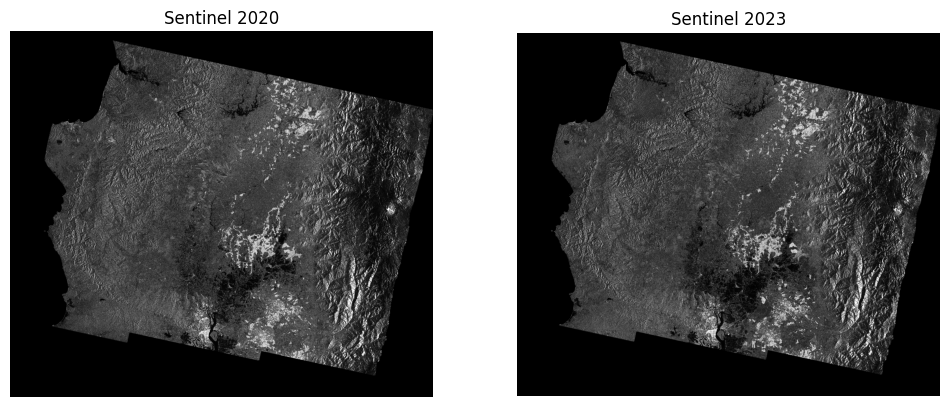

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

base = "/content/drive/MyDrive/"

def leer(ruta):
    with rasterio.open(ruta) as src:
        img = src.read(1, out_shape=(src.height//10, src.width//10))
    img = np.nan_to_num(img)
    p2, p98 = np.percentile(img, (2, 98))
    img = np.clip(img, p2, p98)
    img = (img - p2) / (p98 - p2)
    return img

img2020 = leer(base+"SENTINEL_GUAYAS_2020.tif")
img2023 = leer(base+"SENTINEL_GUAYAS_2023.tif")

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].imshow(img2020, cmap="gray")
ax[0].set_title("Sentinel 2020")

ax[1].imshow(img2023, cmap="gray")
ax[1].set_title("Sentinel 2023")

for a in ax:
    a.axis("off")

plt.show()

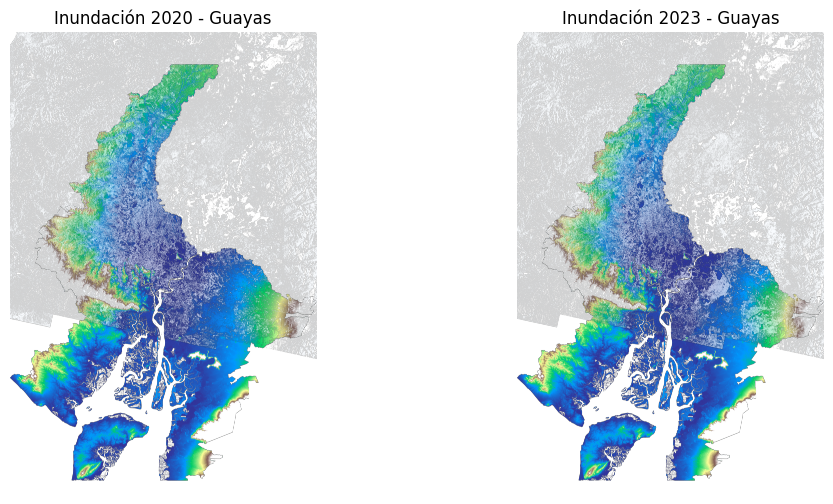

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt

base = "/content/drive/MyDrive/"

# DEM (referencia)
with rasterio.open(base+"DEM_32717.tif") as ref:
    dem = ref.read(1)
    transform = ref.transform
    crs = ref.crs
    shape = dem.shape

dem = np.nan_to_num(dem)
p2, p98 = np.percentile(dem, (2, 98))
dem = (np.clip(dem, p2, p98) - p2) / (p98 - p2)

# función para alinear raster al DEM
def alinear(ruta):
    with rasterio.open(ruta) as src:
        destino = np.empty(shape, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=destino,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=crs,
            resampling=Resampling.bilinear
        )

    return np.nan_to_num(destino)

img1 = alinear(base+"SENTINEL_GUAYAS_2020.tif")
img2 = alinear(base+"SENTINEL_GUAYAS_2023.tif")

# normalización
def normalizar(img):
    p2, p98 = np.percentile(img, (2, 98))
    return (np.clip(img, p2, p98) - p2) / (p98 - p2)

img1 = normalizar(img1)
img2 = normalizar(img2)

# detección de agua (ajustable)
umbral = 0.3
agua_2020 = np.where((img1 < umbral) & (img1 > 0.05), 1, np.nan)
agua_2023 = np.where((img2 < umbral) & (img2 > 0.05), 1, np.nan)

dem = np.where(dem <= 0, np.nan, dem)

# visualización FINAL correcta
fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].imshow(dem, cmap="terrain")
ax[0].imshow(agua_2020, cmap="Blues", alpha=0.7)
ax[0].set_title("Inundación 2020 - Guayas")

ax[1].imshow(dem, cmap="terrain")
ax[1].imshow(agua_2023, cmap="Blues", alpha=0.7)
ax[1].set_title("Inundación 2023 - Guayas")

for a in ax:
    a.axis("off")

plt.show()

**CONSTRUCCIÓN DEL STACK**

In [4]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np

base = "/content/drive/MyDrive/"

with rasterio.open(base+"DEM_32717.tif") as ref:
    ref_array = ref.read(1)
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = ref_array.shape

def alinear(ruta, metodo):
    with rasterio.open(ruta) as src:
        destino = np.empty(ref_shape, dtype=np.float32)

        reproject(
            source=rasterio.band(src, 1),
            destination=destino,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=metodo
        )

    return destino

dem = alinear(base+"DEM_32717.tif", Resampling.bilinear)
chirps = alinear(base+"CHIRPS_32717.tif", Resampling.bilinear)
suelo = alinear(base+"SUELO_32717.tif", Resampling.bilinear)

sentinel_2020 = alinear(base+"SENTINEL_2020_RECORTADO.tif", Resampling.nearest)
sentinel_2023 = alinear(base+"SENTINEL_2023_RECORTADO.tif", Resampling.nearest)

stack = np.stack([
    dem,
    chirps,
    suelo,
    sentinel_2020,
    sentinel_2023
], axis=0)

print("Stack:", stack.shape)

print("Sentinel 2020 min/max:", np.nanmin(sentinel_2020), np.nanmax(sentinel_2020))
print("Sentinel 2023 min/max:", np.nanmin(sentinel_2023), np.nanmax(sentinel_2023))

Stack: (5, 7979, 5287)
Sentinel 2020 min/max: 0.0 77.61465
Sentinel 2023 min/max: 0.0 325.21942


In [5]:
stack[stack == -9999] = np.nan

**DATA SET DE ENTRENAMIENTO**






In [6]:
print(stack.shape)

for i in range(stack.shape[0]):
    print(f"Capa {i}: min={np.nanmin(stack[i])}, max={np.nanmax(stack[i])}")

(5, 7979, 5287)
Capa 0: min=-5.5, max=1716.03466796875
Capa 1: min=-9998.9990234375, max=78.06185150146484
Capa 2: min=0.0, max=382.33636474609375
Capa 3: min=0.0, max=77.6146469116211
Capa 4: min=0.0, max=325.21942138671875


In [7]:
import pandas as pd

In [8]:
n_vars, filas, cols = stack.shape

X = stack.reshape(n_vars, -1).T

columnas = [
    "DEM",
    "CHIRPS",
    "SUELO",
    "SENTINEL_2020",
    "SENTINEL_2023"
]

df = pd.DataFrame(X, columns=columnas)

print(df.head())
print("Shape:", df.shape)

   DEM       CHIRPS  SUELO  SENTINEL_2020  SENTINEL_2023
0  0.0 -4804.429199    0.0            0.0            0.0
1  0.0 -4770.743652    0.0            0.0            0.0
2  0.0 -4737.058105    0.0            0.0            0.0
3  0.0 -4703.373047    0.0            0.0            0.0
4  0.0 -4669.687500    0.0            0.0            0.0
Shape: (42184973, 5)


In [9]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

df = df[df["DEM"] > 0]
df = df[df["SENTINEL_2023"] > 0]

print(df.head())
print("Shape limpio:", df.shape)

              DEM  CHIRPS       SUELO  SENTINEL_2020  SENTINEL_2023
2952917  2.492884     0.0  168.053696       0.085612       0.177616
2952918  7.892602     0.0  188.262405       0.029424       0.024996
2952919  7.885396     0.0  208.471115       0.009971       0.017946
2952920  7.878191     0.0  222.999786       0.026209       0.021631
2952921  9.612848     0.0  235.120010       0.095088       0.268413
Shape limpio: (2250076, 5)


In [10]:
df["SENTINEL_2020"] = (df["SENTINEL_2020"] - df["SENTINEL_2020"].min()) / (df["SENTINEL_2020"].max() - df["SENTINEL_2020"].min())

df["SENTINEL_2023"] = (df["SENTINEL_2023"] - df["SENTINEL_2023"].min()) / (df["SENTINEL_2023"].max() - df["SENTINEL_2023"].min())

print(df[["SENTINEL_2020", "SENTINEL_2023"]].describe())

       SENTINEL_2020  SENTINEL_2023
count   2.250076e+06   2.250076e+06
mean    2.635859e-03   5.719667e-04
std     2.775674e-03   1.137112e-03
min     0.000000e+00   0.000000e+00
25%     1.332415e-03   2.546767e-04
50%     2.098900e-03   4.420503e-04
75%     3.205293e-03   7.052483e-04
max     1.000000e+00   1.000000e+00


In [11]:
print(df["SENTINEL_2023"].quantile([0.01, 0.02, 0.05, 0.1, 0.2]))

0.01    0.000017
0.02    0.000022
0.05    0.000039
0.10    0.000090
0.20    0.000211
Name: SENTINEL_2023, dtype: float64


In [12]:
umbral = df["SENTINEL_2023"].quantile(0.30)

df["inundacion"] = np.where(df["SENTINEL_2023"] < umbral, 1, 0)

print(df["inundacion"].value_counts(normalize=True))

inundacion
0    0.7
1    0.3
Name: proportion, dtype: float64


In [13]:
df = df.reset_index(drop=True)

print(df.head())
print("Shape final:", df.shape)

        DEM  CHIRPS       SUELO  SENTINEL_2020  SENTINEL_2023  inundacion
0  2.492884     0.0  168.053696       0.001103       0.000545           0
1  7.892602     0.0  188.262405       0.000379       0.000076           1
2  7.885396     0.0  208.471115       0.000128       0.000054           1
3  7.878191     0.0  222.999786       0.000338       0.000066           1
4  9.612848     0.0  235.120010       0.001225       0.000825           0
Shape final: (2250076, 6)


In [14]:
X = df.drop(columns=["inundacion", "SENTINEL_2023"])
y = df["inundacion"]

print(X.shape)
print(y.shape)

(2250076, 4)
(2250076,)


In [15]:
df.to_csv("/content/dataset_inundaciones.csv", index=False)

print("Dataset guardado correctamente")

Dataset guardado correctamente


**ENTRENAMIENTO Y EVALUACIÓN DE LOS MODELOS**

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1575053, 4) (1575053,)
Test: (675023, 4) (675023,)


Random forest

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nReporte:\n", classification_report(y_test, y_pred_rf))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7787438353952384

Reporte:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85    472516
           1       0.68      0.49      0.57    202507

    accuracy                           0.78    675023
   macro avg       0.74      0.70      0.71    675023
weighted avg       0.77      0.78      0.77    675023


Matriz de confusión:
 [[425889  46627]
 [102726  99781]]


XGBoost

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

modelo_xgb.fit(X_train, y_train)

y_pred_xgb = modelo_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nReporte:\n", classification_report(y_test, y_pred_xgb))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7897256834211575

Reporte:
               precision    recall  f1-score   support

           0       0.81      0.92      0.86    472516
           1       0.73      0.48      0.58    202507

    accuracy                           0.79    675023
   macro avg       0.77      0.70      0.72    675023
weighted avg       0.78      0.79      0.78    675023


Matriz de confusión:
 [[435753  36763]
 [105177  97330]]


In [19]:
resultados = pd.DataFrame({
    "Real": y_test.values,
    "RF": y_pred_rf,
    "XGB": y_pred_xgb
})

print(resultados.head(50))

    Real  RF  XGB
0      0   0    0
1      0   0    0
2      1   1    0
3      0   0    0
4      0   0    0
5      0   0    0
6      1   1    1
7      0   1    1
8      0   0    0
9      1   0    0
10     0   0    0
11     0   0    0
12     0   1    1
13     1   0    0
14     1   0    0
15     0   0    1
16     0   0    0
17     0   0    0
18     0   0    0
19     0   0    0
20     0   0    0
21     0   0    0
22     1   1    1
23     0   0    0
24     0   0    0
25     0   0    0
26     0   0    0
27     0   0    0
28     1   1    1
29     1   1    1
30     0   0    0
31     0   0    0
32     0   0    0
33     1   0    0
34     1   0    0
35     0   0    0
36     0   0    0
37     0   0    0
38     0   0    0
39     0   0    0
40     0   0    0
41     0   0    0
42     0   0    0
43     1   0    0
44     0   0    0
45     0   0    0
46     0   0    0
47     1   1    0
48     1   0    0
49     0   0    0


**VALIDACIÓN ESPACIAL**

In [20]:
rows, cols_grid = np.indices((7979, 5287))

In [21]:
df = pd.DataFrame(X, columns=columnas)

In [22]:
df["row"] = rows.flatten()[:len(df)]
df["col"] = cols_grid.flatten()[:len(df)]

In [23]:
df["bloque"] = (df["row"] // 100) + (df["col"] // 100)

In [24]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(df, groups=df["bloque"]))

X_train_sp = X.iloc[train_idx]
X_test_sp = X.iloc[test_idx]
y_train_sp = y.iloc[train_idx]
y_test_sp = y.iloc[test_idx]

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

modelo_rf_sp = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf_sp.fit(X_train_sp, y_train_sp)

y_pred_rf_sp = modelo_rf_sp.predict(X_test_sp)

print("RF espacial:", accuracy_score(y_test_sp, y_pred_rf_sp))

RF espacial: 0.7802643234747821


In [26]:
from xgboost import XGBClassifier

modelo_xgb_sp = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
modelo_xgb_sp.fit(X_train_sp, y_train_sp)

y_pred_xgb_sp = modelo_xgb_sp.predict(X_test_sp)

print("XGB espacial:", accuracy_score(y_test_sp, y_pred_xgb_sp))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:59:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB espacial: 0.7922003143306187


VALIDACIÓN ESPACIAL Y COMPARACIÓN DE MODELOS

In [27]:
rf_normal = 0.778
xgb_normal = 0.789

rf_espacial = 0.7802643234747821
xgb_espacial = 0.7922003143306187

import pandas as pd

comparacion = pd.DataFrame({
    "Modelo": ["Random Forest", "XGBoost"],
    "Normal": [rf_normal, xgb_normal],
    "Espacial": [rf_espacial, xgb_espacial]
})

comparacion["Diferencia"] = comparacion["Espacial"] - comparacion["Normal"]

print(comparacion)

          Modelo  Normal  Espacial  Diferencia
0  Random Forest   0.778  0.780264    0.002264
1        XGBoost   0.789  0.792200    0.003200


**RESULTADOS**

In [ ]:
# quitar formato % para trabajar numéricamente
tabla_final["% Inundación"] = tabla_final["% Inundación"].str.replace("%","").astype(float)

# nueva clasificación coherente con tu 30%
def clasificar(x):
    if x >= 40:
        return "Alta"
    elif x >= 15:
        return "Media"
    else:
        return "Baja"

tabla_final["Susceptibilidad"] = tabla_final["% Inundación"].apply(clasificar)

# volver a formatear %
tabla_final["% Inundación"] = tabla_final["% Inundación"].map(lambda x: f"{x:.2f}%")

# ordenar y enumerar
tabla_final = tabla_final.sort_values("% Inundación", ascending=False).reset_index(drop=True)
tabla_final.index = tabla_final.index + 1
tabla_final.index.name = "N°"

from IPython.display import display
display(tabla_final)

print("Total parroquias:", tabla_final.shape[0])

,Parroquia,% Inundación,Susceptibilidad
N°,,,
1,GeneralPedroJ.Montero(Bolich,9.29%,Baja
2,Tarifa,80.91%,Alta
3,LaVictoria(Ñauza),76.25%,Alta
4,Puna,69.33%,Alta
5,JuanBautistaAguirre(LosTinto,63.11%,Alta
6,MariscalSucre(Huaques),6.54%,Baja
7,RobertoAstudillo(Cab.EnCruce,6.03%,Baja
8,Limonal,59.13%,Alta
9,Laurel,53.36%,Alta


Total parroquias: 29


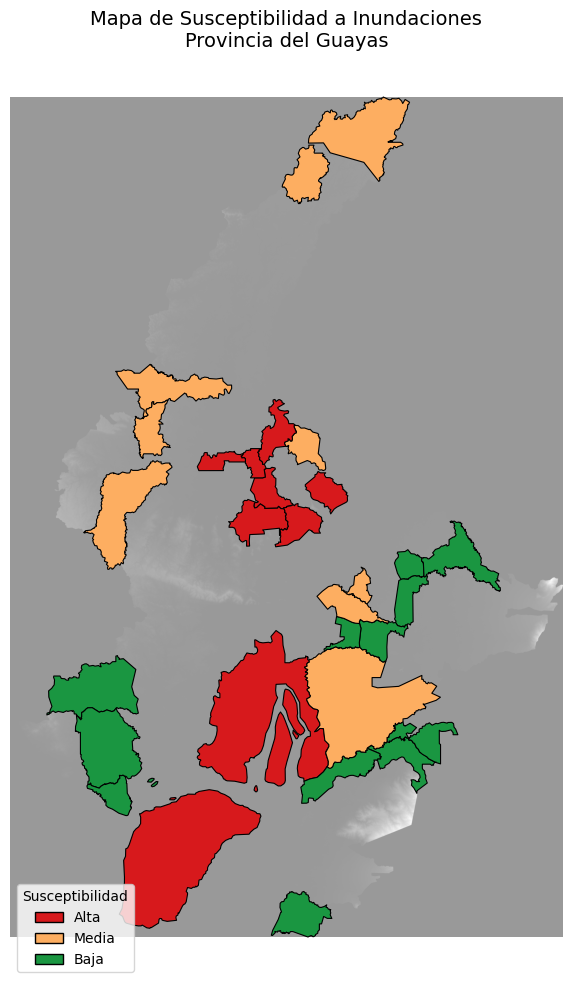

In [ ]:
import rasterio
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------- 1. CARGAR DEM (MAPA BASE) ----------
ruta_dem = "/content/drive/MyDrive/DEM_GUAYAS_2.tif"

with rasterio.open(ruta_dem) as src:
    dem = src.read(1)
    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top
    ]

# ---------- 2. COLORES ----------
colores = {
    "Alta": "#d7191c",
    "Media": "#fdae61",
    "Baja": "#1a9641"
}

mapa["color"] = mapa["Susceptibilidad"].map(colores)

# ---------- 3. GRAFICAR ----------
fig, ax = plt.subplots(figsize=(10,12))

# fondo raster (mapa completo)
ax.imshow(dem, extent=extent, cmap="gray", alpha=0.4)

# parroquias encima
mapa.plot(ax=ax, color=mapa["color"], edgecolor="black", linewidth=0.8)

# título
ax.set_title("Mapa de Susceptibilidad a Inundaciones\nProvincia del Guayas", fontsize=14)

# quitar ejes
ax.axis("off")

# ---------- 4. LEYENDA ----------
leyenda = [
    Patch(facecolor="#d7191c", edgecolor="black", label="Alta"),
    Patch(facecolor="#fdae61", edgecolor="black", label="Media"),
    Patch(facecolor="#1a9641", edgecolor="black", label="Baja")
]

ax.legend(handles=leyenda, title="Susceptibilidad", loc="lower left")

plt.show()